# Set-up

In [1]:
import os
import sys
import glob
import json
import numpy as np
import pandas as pd
import pyBigWig
import matplotlib.pyplot as plt
import seaborn as sns

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
def plot_tracks(tracks, interval, height=1.5, colors=None, sharey=False):
  _, axes = plt.subplots(len(tracks), 1, figsize=(20, height * len(tracks)), sharex=True, sharey=sharey)
  if not isinstance(axes, np.ndarray):
    axes = [axes]
  for ax, (title, y) in zip(axes, tracks.items()):
    if colors is not None:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y, color=colors[title])
    else:
      ax.fill_between(np.linspace(interval["start"], interval["end"], num=len(y)), y)
    ax.set_title(title)
    sns.despine(top=True, right=True, bottom=True)
  ax.set_xlabel(f"{interval['chrom']}:{interval['start']}-{interval['end']}")
  plt.tight_layout()

def plot_tracks_from_locus(locus, bws, colors, sharey=False):
    chrom, coord = locus.split(":")
    start, end = coord.split("-")
    start, end = int(start), int(end)
    interval = {"chrom": chrom, "start": int(start), "end": int(end)}
    tracks = {k: np.nan_to_num(np.array(bw.values(chrom, start, end))) for k, bw in bws.items()}
    plot_tracks(tracks, interval, height=1.5, colors=colors, sharey=sharey)

In [3]:
sys.path.append("/cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome")
from config.loader import load_colors

In [4]:
ct_colors = load_colors("Muto_mouse-kidney_10X-Multiome")["celltype_colors"]
ct_order = load_colors("Muto_mouse-kidney_10X-Multiome")["celltype_order"]

In [5]:
path_bigwigs = "/cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset"

In [6]:
paths_bigwigs = glob.glob(os.path.join(path_bigwigs, "*.bw"))
len(paths_bigwigs)

22

In [7]:
bw_dict = {os.path.basename(p).replace(".bw", ""): pyBigWig.open(p) for p in paths_bigwigs}
bw_dict.keys()

dict_keys(['PODO', 'Tcell', 'DTL1', 'FRPTC_PEC', 'ENDO', 'DTL2', 'PC2', 'PTS2', 'PTS3', 'FIB', 'PC1', 'PTS1', 'DCT', 'Myel', 'ICA', 'FAT', 'ATL', 'Bcell', 'ICB', 'CNT', 'URO', 'TAL'])

In [8]:
# Subset 5 random cell types to plot from ct_order
cts_to_plot = np.random.choice(ct_order, size=5, replace=False).tolist()
cts_to_plot

['Tcell', 'Myel', 'DTL1', 'FRPTC_PEC', 'URO']

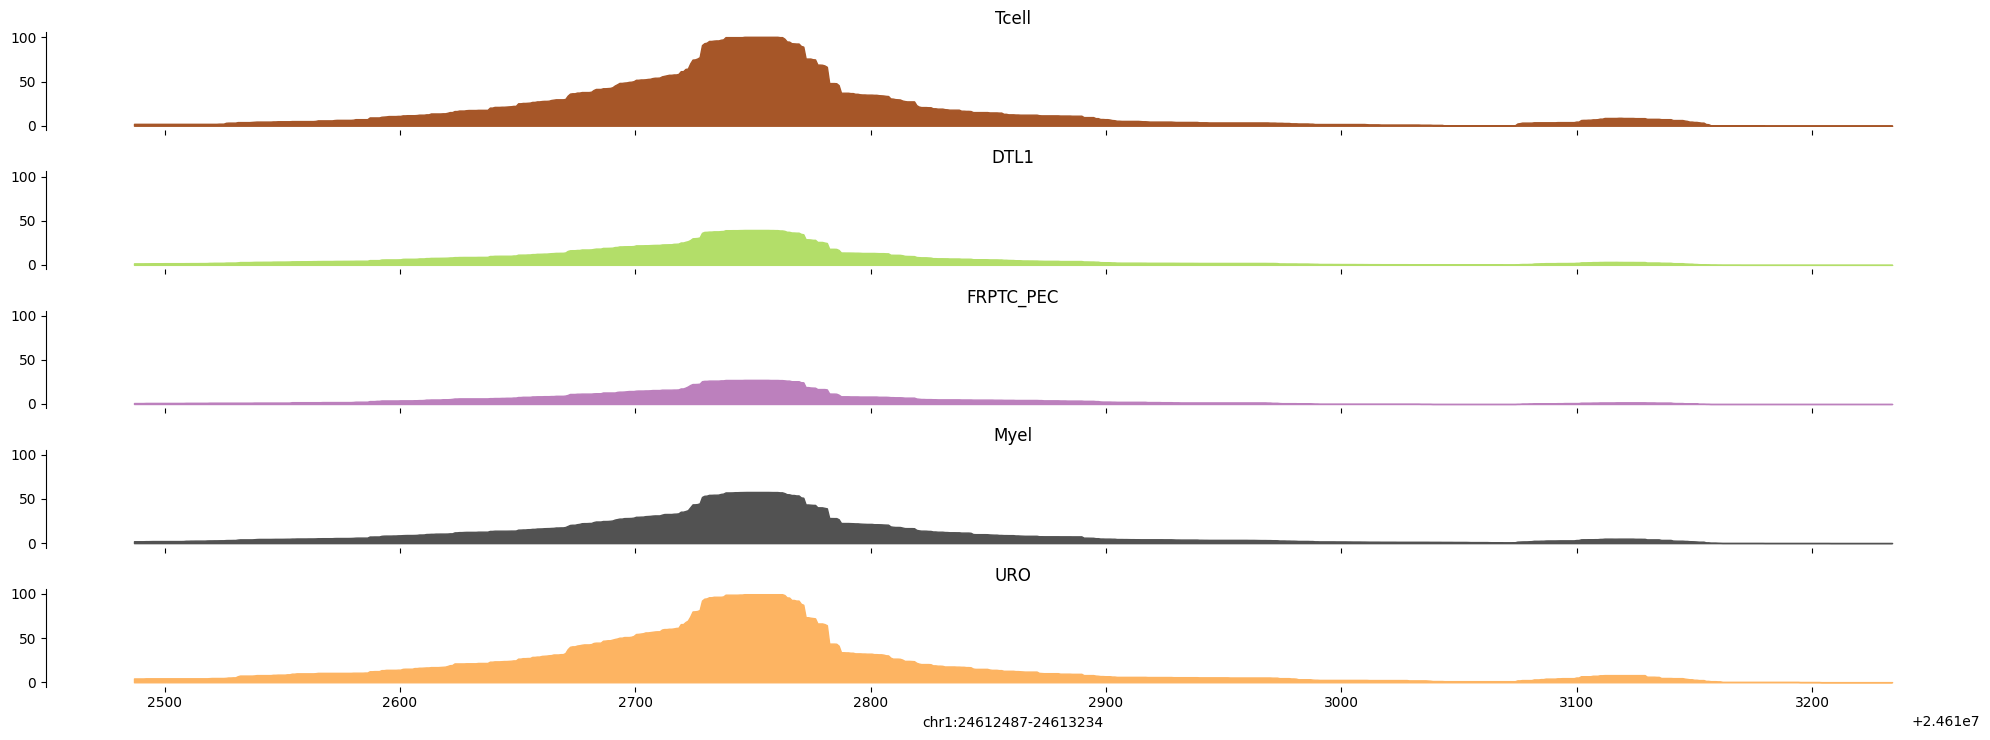

In [9]:
locus = "chr1:24612487-24613234"
plot_tracks_from_locus(locus, {k: v for k, v in bw_dict.items() if k in cts_to_plot}, {k: v for k, v in ct_colors.items() if k in cts_to_plot}, sharey=True)

In [13]:
!gcloud auth list

                      Credentialed Accounts
ACTIVE  ACCOUNT
*       adamklie13@gmail.com
        adamklie@igvf-pertub-seq-pipeline.iam.gserviceaccount.com
        aklie@eng.ucsd.edu
        aklie@ucsd.edu
        archive-aklie@eng.ucsd.edu

To set the active account, run:
    $ gcloud config set account `ACCOUNT`



In [15]:
# Secure copy all bigwig files to bucket
for cell_type in bw_dict.keys():
    path = os.path.join(path_bigwigs, f"{cell_type}.bw")
    cmd = f"gsutil cp {path} gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/bigWig/{cell_type}.ATAC.fpm.bw"
    print(cmd)
    os.system(cmd)

gsutil cp /cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/PODO.bw gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/bigWig/PODO.ATAC.fpm.bw


Copying file:///cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/PODO.bw [Content-Type=application/octet-stream]...
/ [1 files][ 17.1 MiB/ 17.1 MiB]                                                
Operation completed over 1 objects/17.1 MiB.                                     


gsutil cp /cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/Tcell.bw gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/bigWig/Tcell.ATAC.fpm.bw


Copying file:///cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/Tcell.bw [Content-Type=application/octet-stream]...
- [1 files][ 23.6 MiB/ 23.6 MiB]                                                
Operation completed over 1 objects/23.6 MiB.                                     


gsutil cp /cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/DTL1.bw gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/bigWig/DTL1.ATAC.fpm.bw


...

Copying file:///cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/CNT.bw [Content-Type=application/octet-stream]...
==> NOTE: You are uploading one or more large file(s), which would run          
significantly faster if you enable parallel composite uploads. This
feature can be enabled by editing the
"parallel_composite_upload_threshold" value in your .boto
configuration file. However, note that if you do this large files will
be uploaded as `composite objects
<https://cloud.google.com/storage/docs/composite-objects>`_,which
means that any user who downloads such objects will need to have a
compiled crcmod installed (see "gsutil help crcmod"). This is because
without a compiled crcmod, computing checksums on composite objects is
so slow that gsutil disables downloads of composite objects.

- [1 files][215.5 MiB/215.5 MiB]                                                
Operation completed over 1 objects/215.5 MiB.                            

gsutil cp /cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/URO.bw gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/bigWig/URO.ATAC.fpm.bw


Copying file:///cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/URO.bw [Content-Type=application/octet-stream]...
- [1 files][ 25.7 MiB/ 25.7 MiB]                                                
Operation completed over 1 objects/25.7 MiB.                                     


gsutil cp /cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/TAL.bw gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/bigWig/TAL.ATAC.fpm.bw


Copying file:///cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/subset/TAL.bw [Content-Type=application/octet-stream]...
==> NOTE: You are uploading one or more large file(s), which would run          
significantly faster if you enable parallel composite uploads. This
feature can be enabled by editing the
"parallel_composite_upload_threshold" value in your .boto
configuration file. However, note that if you do this large files will
be uploaded as `composite objects
<https://cloud.google.com/storage/docs/composite-objects>`_,which
means that any user who downloads such objects will need to have a
compiled crcmod installed (see "gsutil help crcmod"). This is because
without a compiled crcmod, computing checksums on composite objects is
so slow that gsutil disables downloads of composite objects.

| [1 files][531.9 MiB/531.9 MiB]                                                
Operation completed over 1 objects/531.9 MiB.                            

# Datahub configuration

In [16]:
# Create dataframe for browser tracks
df = pd.DataFrame([
    {
        "type": "bigwig",
        "url": f"https://storage.googleapis.com/kidney_enhancers/Muto_mouse-kidney_10X-Multiome/bigWig/{cell_type}.ATAC.fpm.bw",
        "name": f"{cell_type} ATAC",
        "options": {"color": ct_colors[cell_type]},
        "metadata": {"sample": cell_type, "assay": "ATAC"}
    }
    for cell_type in bw_dict.keys()
])

df.head()

,type,url,name,options,metadata
0,bigwig,https://storage.googleapis.com/kidney_enhancer...,PODO ATAC,{'color': '#e41a1c'},"{'sample': 'PODO', 'assay': 'ATAC'}"
1,bigwig,https://storage.googleapis.com/kidney_enhancer...,Tcell ATAC,{'color': '#a65628'},"{'sample': 'Tcell', 'assay': 'ATAC'}"
2,bigwig,https://storage.googleapis.com/kidney_enhancer...,DTL1 ATAC,{'color': '#b3de69'},"{'sample': 'DTL1', 'assay': 'ATAC'}"
3,bigwig,https://storage.googleapis.com/kidney_enhancer...,FRPTC_PEC ATAC,{'color': '#bc80bd'},"{'sample': 'FRPTC_PEC', 'assay': 'ATAC'}"
4,bigwig,https://storage.googleapis.com/kidney_enhancer...,ENDO ATAC,{'color': '#ff7f00'},"{'sample': 'ENDO', 'assay': 'ATAC'}"


In [17]:
# Set your global limits
ymin, ymax = 0, 3

json_tracks = [
    {
        "type": row["type"],
        "url": row["url"],
        "name": row["name"],
        "options": {
            **row["options"],   # keep existing color
            "yMin": ymin,
            "yMax": ymax,
            "yScale": "fixed"   # tell WashU to respect these limits
        },
        "metadata": row["metadata"],
        "showOnHubLoad": True
    }
    for _, row in df.iterrows()
]

In [18]:
# Order tracks by first part of celltype name (before underscore)
json_tracks = sorted(json_tracks, key=lambda x: x["metadata"]["sample"].split("_")[0])

In [19]:
# Write JSON to file
out_path = "/cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/Muto_mouse-kidney_10X-Multiome_ATAC_fpm_bigWigs.json"
with open(out_path, "w") as f:
    json.dump(json_tracks, f, indent=4)

print(f"Wrote {len(json_tracks)} tracks to {out_path}")

Wrote 22 tracks to /cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/Muto_mouse-kidney_10X-Multiome_ATAC_fpm_bigWigs.json


In [20]:
# Write the file to the bucket
cmd = f"gsutil cp {out_path} gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/data_hubs/Muto_mouse-kidney_10X-Multiome_ATAC_fpm_bigWigs.json"
print(cmd)
os.system(cmd)

gsutil cp /cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/Muto_mouse-kidney_10X-Multiome_ATAC_fpm_bigWigs.json gs://kidney_enhancers/Muto_mouse-kidney_10X-Multiome/data_hubs/Muto_mouse-kidney_10X-Multiome_ATAC_fpm_bigWigs.json


Copying file:///cellar/users/aklie/data/datasets/Muto_mouse-kidney_10X-Multiome/results/2_process_data/Muto_mouse-kidney_10X-Multiome_ATAC_fpm_bigWigs.json [Content-Type=application/json]...
/ [1 files][  9.7 KiB/  9.7 KiB]                                                
Operation completed over 1 objects/9.7 KiB.                                      


0

# DONE!

---